<a href="https://colab.research.google.com/github/one-2730/ESAA-24-2/blob/Assignment/ESAA_YB_1108_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##릿지 회귀

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
boston = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :3]])
feature_names=['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'PRICE']
bostonDF = pd.DataFrame(boston, columns = feature_names)

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis = 1, inplace = False)

ridge = Ridge(alpha = 10)
neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring = 'neg_mean_squared_error', cv = 5)
rmse_scores = np.sqrt(-1*neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print('5 folds 의 개별 Negative MSE soces:', np.round(neg_mse_scores, 3))
print('5 folds 의 개별 RMSE scores:', np.round(rmse_scores, 3))
print('5 folds 의 평균 RMSE:', np.round(avg_rmse, 3))

5 folds 의 개별 Negative MSE soces: [-11.422 -24.294 -28.144 -74.599 -28.517]
5 folds 의 개별 RMSE scores: [3.38  4.929 5.305 8.637 5.34 ]
5 folds 의 평균 RMSE: 5.518


In [2]:
alphas = [0, 0.1, 1, 10, 100]

for alpha in alphas:
  ridge = Ridge(alpha = alpha)

  neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring = 'neg_mean_squared_error', cv = 5)
  avg_rmse = np.mean(np.sqrt(-1*neg_mse_scores))
  print('alpha{0} 일 때 5 folds의 평균 RMSE: {1:.3f}'.format(alpha, avg_rmse))

alpha0 일 때 5 folds의 평균 RMSE: 5.829
alpha0.1 일 때 5 folds의 평균 RMSE: 5.788
alpha1 일 때 5 folds의 평균 RMSE: 5.653
alpha10 일 때 5 folds의 평균 RMSE: 5.518
alpha100 일 때 5 folds의 평균 RMSE: 5.330


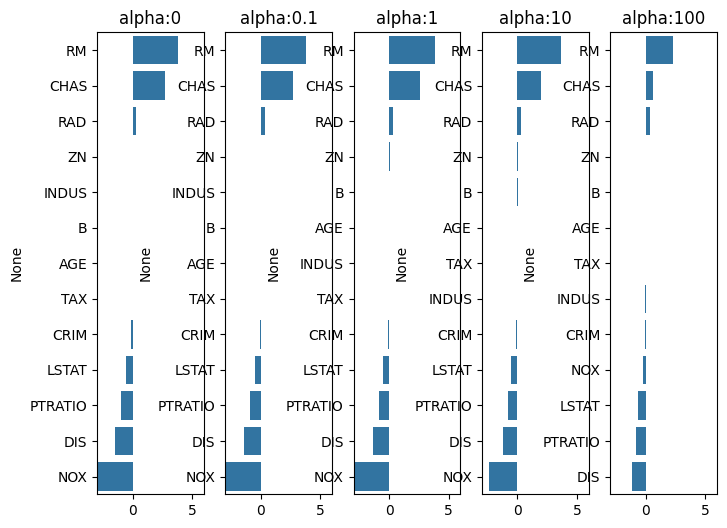

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(figsize = (8, 6), nrows = 1, ncols = 5)
coeff_df = pd.DataFrame()

for pos, alpha in enumerate(alphas):
  ridge = Ridge(alpha = alpha)
  ridge.fit(X_data, y_target)
  coeff = pd.Series(data = ridge.coef_, index = X_data.columns)
  colname = 'alpha:'+str(alpha)
  coeff_df[colname] = coeff
  coeff = coeff.sort_values(ascending = False)
  axs[pos].set_title(colname)
  axs[pos].set_xlim(-3, 6)
  sns.barplot(x = coeff.values, y = coeff.index, ax = axs[pos])

plt.show()

In [4]:
ridge_alphas = [0, 0.1, 1, 10, 100]
sort_column = 'alpha:'+str(ridge_alphas[0])
coeff_df.sort_values(by = sort_column, ascending = False)

,alpha:0,alpha:0.1,alpha:1,alpha:10,alpha:100
RM,3.809865,3.818233,3.854000,3.702272,2.334536
CHAS,2.686734,2.670019,2.552393,1.952021,0.638335
RAD,0.306049,0.303515,0.290142,0.279596,0.315358
ZN,0.046420,0.046572,0.047443,0.049579,0.054496
INDUS,0.020559,0.015999,-0.008805,-0.042962,-0.052826
B,0.009312,0.009368,0.009673,0.010037,0.009393
AGE,0.000692,-0.000269,-0.005415,-0.010707,0.001212
TAX,-0.012335,-0.012421,-0.012912,-0.013993,-0.015856
CRIM,-0.108011,-0.107474,-0.104595,-0.101435,-0.102202
LSTAT,-0.524758,-0.525966,-0.533343,-0.559366,-0.660764


##라쏘 회귀

W의 절댓값에 패널티를 부여하는 L1 규제를 선형회귀에 적용
RSS(W) + alpha *|W|를 최소화하는 W 찾기

In [5]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Lasso, ElasticNet

def get_linear_reg_eval(model_name, params = None, X_data_n = None, y_target_n = None, verbose = True, return_coeff = True):
  coeff_df = pd.DataFrame()
  if verbose : print('#####', model_name, '#####')
  for param in params:
    if model_name == 'Ridge': model = Ridge(alpha = param)
    elif model_name == 'Lasso': model = Lasso(alpha = param)
    elif model_name == 'ElasticNet': model = ElasticNet(alpha = param, l1_ratio = 0.7)
    neg_mse_scores = cross_val_score(model, X_data_n, y_target_n, scoring = 'neg_mean_squared_error', cv = 5)
    avg_rmse = np.mean(np.sqrt(-1*neg_mse_scores))
    print('alpha {0}일 때 5 folds set average RMSE: {1:.3f}'.format(param, avg_rmse))

    model.fit(X_data_n, y_target_n)
    if return_coeff:
      coeff = pd.Series(data = model.coef_, index = X_data_n.columns)
      colname = 'alpha:'+str(param)
      coeff_df[colname] = coeff

  return coeff_df

lasso_alphas = [0, 0.7, 0.1, 0.5, 1, 3]
coeff_lasso_df = get_linear_reg_eval('Lasso', params = lasso_alphas, X_data_n = X_data, y_target_n = y_target)

##### Lasso #####
alpha 0일 때 5 folds set average RMSE: 5.829
alpha 0.7일 때 5 folds set average RMSE: 5.727
alpha 0.1일 때 5 folds set average RMSE: 5.615
alpha 0.5일 때 5 folds set average RMSE: 5.669
alpha 1일 때 5 folds set average RMSE: 5.776
alpha 3일 때 5 folds set average RMSE: 6.189


In [6]:
sort_column = 'alpha:'+str(lasso_alphas[0])
coeff_lasso_df.sort_values(by = sort_column, ascending = False)

,alpha:0,alpha:0.7,alpha:0.1,alpha:0.5,alpha:1,alpha:3
RM,3.809865,1.881473,3.703202,2.498212,0.949811,0.000000
CHAS,2.686734,0.000000,0.955190,0.000000,0.000000,0.000000
RAD,0.306049,0.273007,0.274707,0.277451,0.264206,0.061864
ZN,0.046420,0.049480,0.049211,0.049544,0.049165,0.037231
INDUS,0.020559,-0.000000,-0.036619,-0.005253,-0.000000,-0.000000
B,0.009312,0.008987,0.010249,0.009469,0.008247,0.006510
AGE,0.000692,0.010470,-0.010037,0.003604,0.020910,0.042495
TAX,-0.012335,-0.015444,-0.014570,-0.015442,-0.015212,-0.008602
CRIM,-0.108011,-0.075242,-0.097894,-0.083289,-0.063437,-0.000000
LSTAT,-0.524758,-0.698471,-0.568769,-0.656290,-0.761115,-0.807679


##엘라스틱넷 회귀

L2 규제와 L1규제를 결합한 회귀.
RSS(W) +alpha2*|W|_2 + alpha1*|W|_1를 최소화하는 W를 찾기

In [7]:
elastic_alphas = [0, 0.07, 0.1, 0.5, 1, 3]
coeff_elastic_df = get_linear_reg_eval('ElasticNet', params = elastic_alphas, X_data_n = X_data, y_target_n = y_target)

##### ElasticNet #####
alpha 0일 때 5 folds set average RMSE: 5.829
alpha 0.07일 때 5 folds set average RMSE: 5.542
alpha 0.1일 때 5 folds set average RMSE: 5.526
alpha 0.5일 때 5 folds set average RMSE: 5.467
alpha 1일 때 5 folds set average RMSE: 5.597
alpha 3일 때 5 folds set average RMSE: 6.068


In [8]:
sor_colun = 'alpha:'+str(elastic_alphas[0])
coeff_elastic_df.sort_values(by = sort_column, ascending = False)

,alpha:0,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
RM,3.809865,3.574162,3.414154,1.918419,0.938789,0.000000
CHAS,2.686734,1.330724,0.979706,0.000000,0.000000,0.000000
RAD,0.306049,0.278880,0.283443,0.300761,0.289299,0.146846
ZN,0.046420,0.050107,0.050617,0.052878,0.052136,0.038268
INDUS,0.020559,-0.044855,-0.042719,-0.023252,-0.000000,-0.000000
B,0.009312,0.010122,0.010067,0.009114,0.008320,0.007020
AGE,0.000692,-0.010116,-0.008276,0.007760,0.020348,0.043446
TAX,-0.012335,-0.014522,-0.014814,-0.016046,-0.016218,-0.011417
CRIM,-0.108011,-0.099468,-0.099213,-0.089070,-0.073577,-0.019058
LSTAT,-0.524758,-0.574822,-0.587702,-0.693861,-0.760457,-0.800368


##선형 회귀 모델을 위한 데이터 변환

1. StandardScaler 클래스를 이용해 평균이 0, 분산이 1인 표준 정규 분포를 가진 데이터 세트로 변환하거나 MinMaxScaler 클래스를 이용해 최솟값이 0이고 최댓값이 1인 값으로 정규화를 수행
2. 스케일링/정규화를 수행한 데이터 세트에 다시 다항 특성을 적용화여 변환. 1번을 먼저 시도해보고 예측 성능 향상이 없으면 2번 적용
3. log변환: 선형 회귀에서는 1, 2보다 log변환이 더 많이 사용됨

In [9]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures

def get_scaled_data(method = 'None', p_degree = None, input_data = None):
  if method == 'Standard':
    scaled_data = StandardScaler().fit_transform(input_data)
  elif method == 'MinMax':
    scaled_data = MinMaxScaler().fit_transform(input_data)
  elif method == 'Log':
    scaled_data = np.log1p(input_data)
  else:
    scaled_data = input_data

  if p_degree != None:
    scaled_data = PolynomialFeatures(degree = p_degree, include_bias = False).fit_transform(scaled_data)

  return scaled_data

alpha = [0.1, 1, 10, 100]

scale_methods = [(None, None), ('Standard', None), ('Standard', 2), ('MinMax', None), ('MinMax', 2), ('Log', None)]
for scaled_method in scale_methods:
  X_data_scaled = get_scaled_data(method = scaled_method[0], p_degree = scaled_method[1], input_data = X_data)
  print('\n 변환 유형: {0}, Polynomial Degree: {1}'.format(scaled_method[0], scaled_method[1]))
  get_linear_reg_eval('Ridge', params = alphas, X_data_n = X_data_scaled, y_target_n = y_target, verbose = False, return_coeff = False)


 변환 유형: None, Polynomial Degree: None
alpha 0일 때 5 folds set average RMSE: 5.829
alpha 0.1일 때 5 folds set average RMSE: 5.788
alpha 1일 때 5 folds set average RMSE: 5.653
alpha 10일 때 5 folds set average RMSE: 5.518
alpha 100일 때 5 folds set average RMSE: 5.330

 변환 유형: Standard, Polynomial Degree: None
alpha 0일 때 5 folds set average RMSE: 5.829
alpha 0.1일 때 5 folds set average RMSE: 5.826
alpha 1일 때 5 folds set average RMSE: 5.803
alpha 10일 때 5 folds set average RMSE: 5.637
alpha 100일 때 5 folds set average RMSE: 5.421

 변환 유형: Standard, Polynomial Degree: 2
alpha 0일 때 5 folds set average RMSE: 65967111408424.500
alpha 0.1일 때 5 folds set average RMSE: 8.827
alpha 1일 때 5 folds set average RMSE: 6.871
alpha 10일 때 5 folds set average RMSE: 5.485
alpha 100일 때 5 folds set average RMSE: 4.634

 변환 유형: MinMax, Polynomial Degree: None
alpha 0일 때 5 folds set average RMSE: 5.829
alpha 0.1일 때 5 folds set average RMSE: 5.764
alpha 1일 때 5 folds set average RMSE: 5.465
alpha 10일 때 5 folds set average R

##로지스틱 회귀

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

X_train, X_test, y_train, y_test = train_test_split(data_scaled, cancer.target, test_size = 0.3, random_state = 0)

from sklearn.metrics import accuracy_score, roc_auc_score

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_preds = lr_clf.predict(X_test)

print('accuracy: {0:.3f}, roc_auc: {1:.3f}'.format(accuracy_score(y_test, lr_preds), roc_auc_score(y_test, lr_preds)))

accuracy: 0.977, roc_auc: 0.972


In [11]:
solvers = ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']

for solver in solvers:
  lr_clf = LogisticRegression(solver = solver, max_iter = 600)
  lr_clf.fit(X_train, y_train)
  lr_preds = lr_clf.predict(X_test)

  print('solver{0}, accuracy: {1:.3f}, roc_auc: {2:.3f}'.format(solver, accuracy_score(y_test, lr_preds), roc_auc_score(y_test, lr_preds)))

solverlbfgs, accuracy: 0.977, roc_auc: 0.972
solverliblinear, accuracy: 0.982, roc_auc: 0.979
solvernewton-cg, accuracy: 0.977, roc_auc: 0.972
solversag, accuracy: 0.982, roc_auc: 0.979
solversaga, accuracy: 0.982, roc_auc: 0.979


In [12]:
from sklearn.model_selection import GridSearchCV

params = {'solver': ['liblinear', 'lbfgs'],
          'penalty': ['l2', 'l1'],
          'C': [0.01, 0.1, 1, 1, 5, 10]}

lr_clf = LogisticRegression()

grid_clf = GridSearchCV(lr_clf, param_grid = params, scoring = 'accuracy', cv = 3)
grid_clf.fit(data_scaled, cancer.target)
print('최적 하이퍼 파라미터: {0}, 최적 평균 정확도: {1:.3f}'.format(grid_clf.best_params_, grid_clf.best_score_))

최적 하이퍼 파라미터: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}, 최적 평균 정확도: 0.979


##회귀 트리

In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

rf = RandomForestRegressor(random_state = 0, n_estimators = 1000)
neg_mse_scores = cross_val_score(rf, X_data, y_target, scoring = 'neg_mean_squared_error', cv = 5)
rmse_scores = np.sqrt(-1*neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print('5 folds 의 개별 Negative MSE soces:', np.round(neg_mse_scores, 2))
print('5 folds 의 개별 RMSE scores:', np.round(rmse_scores, 2))
print('5 folds 의 평균 RMSE:', np.round(avg_rmse, 2))

5 folds 의 개별 Negative MSE soces: [ -7.88 -13.14 -20.57 -46.23 -18.88]
5 folds 의 개별 RMSE scores: [2.81 3.63 4.54 6.8  4.34]
5 folds 의 평균 RMSE: 4.42


In [14]:
def get_model_cv_prediction(model, X_data, y_target):
  neg_mse_scores = cross_val_score(model, X_data, y_target, scoring = 'neg_mean_squared_error', cv = 5)
  rmse_scores = np.sqrt(-1*neg_mse_scores)
  avg_rmse = np.mean(rmse_scores)
  print('#####', model.__class__.__name__, '#####')
  print('5 folds cv의 평균 RMSE: {0:.3f}'.format(avg_rmse))

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

dt_reg = DecisionTreeRegressor(random_state = 0, max_depth = 4)
rf_reg = RandomForestRegressor(random_state = 0, n_estimators = 1000)
gb_reg = GradientBoostingRegressor(random_state = 0, n_estimators = 1000)
xgb_reg = XGBRegressor(n_estimators = 1000)
lgb_reg = LGBMRegressor(n_estimators = 1000, verbose = -1)

models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]
for model in models:
  get_model_cv_prediction(model, X_data, y_target)

##### DecisionTreeRegressor #####
5 folds cv의 평균 RMSE: 5.978
##### RandomForestRegressor #####
5 folds cv의 평균 RMSE: 4.423
##### GradientBoostingRegressor #####
5 folds cv의 평균 RMSE: 4.269
##### XGBRegressor #####
5 folds cv의 평균 RMSE: 4.959
##### LGBMRegressor #####
5 folds cv의 평균 RMSE: 4.646


<Axes: xlabel='None', ylabel='None'>

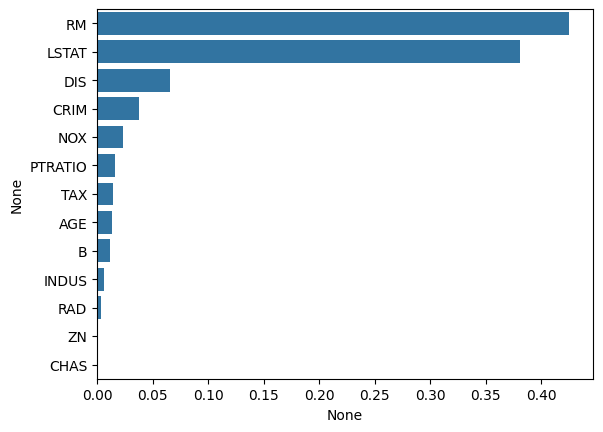

In [15]:
rf_reg = RandomForestRegressor(n_estimators = 1000)

rf_reg.fit(X_data, y_target)

feature_series = pd.Series(data = rf_reg.feature_importances_, index = X_data.columns)
feature_series = feature_series.sort_values(ascending = False)
sns.barplot(x = feature_series, y = feature_series.index)

(100, 2)


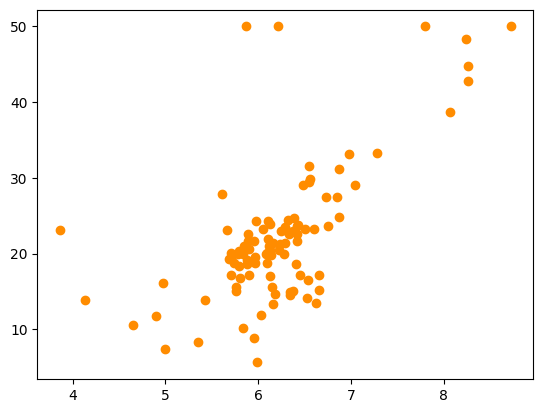

In [16]:
bostonDF_sample = bostonDF[['RM', 'PRICE']]
bostonDF_sample = bostonDF_sample.sample(n = 100, random_state = 0)
print(bostonDF_sample.shape)
plt.figure()
plt.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c = 'darkorange')

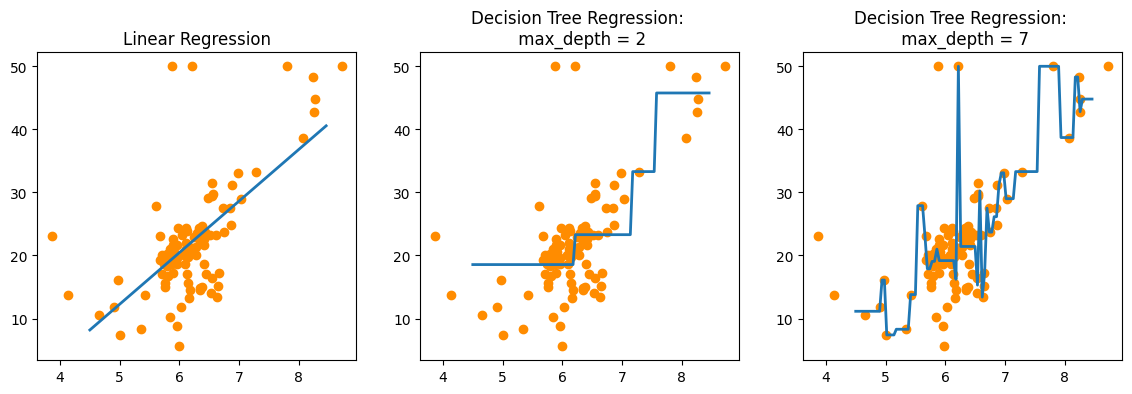

In [17]:
from sklearn.linear_model import LinearRegression

lr_reg = LinearRegression()
dt_reg2 = DecisionTreeRegressor(max_depth = 2)
dt_reg7 = DecisionTreeRegressor(max_depth = 7)

X_test = np.arange(4.5, 8.5, 0.04).reshape(-1, 1)

X_feature = bostonDF_sample['RM'].values.reshape(-1, 1)
y_target = bostonDF_sample['PRICE'].values.reshape(-1, 1)

lr_reg.fit(X_feature, y_target)
dt_reg2.fit(X_feature, y_target)
dt_reg7.fit(X_feature, y_target)

pred_lr = lr_reg.predict(X_test)
pred_dt2 = dt_reg2.predict(X_test)
pred_dt7 = dt_reg7.predict(X_test)

fig, (ax1, ax2, ax3) = plt.subplots(figsize = (14, 4), ncols = 3)

ax1.set_title('Linear Regression')
ax1.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c = 'darkorange')
ax1.plot(X_test, pred_lr, label = 'linear', linewidth = 2)

ax2.set_title('Decision Tree Regression: \n max_depth = 2')
ax2.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c = 'darkorange')
ax2.plot(X_test, pred_dt2, label = 'max_depth: 2', linewidth = 2)

ax3.set_title('Decision Tree Regression: \n max_depth = 7')
ax3.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c = 'darkorange')
ax3.plot(X_test, pred_dt7, label = 'max_depth: 7', linewidth = 2)